# PyTorch 与神经网络模型实践

## 1. PyTorch 基础

### 1.1 张量运算

**请使用 PyTorch 内置函数完成，避免显式循环。**

1. 创建一个形状为 (6, 5) 的随机整数张量 `A`，取值范围为 {0, 1, ..., 10}。打印出该张量；
2. 将 `A` 的每一行减去该行的均值（行中心化），得到张量 `A_centered`，使用广播实现。打印出该张量；
3. 打印出 `A_centered` 的行和向量以及列和向量。

In [36]:
import torch

A = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
print("张量 A:")
print(A)

row_means = A.mean(dim=1, keepdim=True)
A_centered = A - row_means
print("\n行中心化后的张量 A_centered:")
print(A_centered)

row_sums = A_centered.sum(dim=1)
col_sums = A_centered.sum(dim=0)
print("\n行和向量:")
print(row_sums)
print("\n列和向量:")
print(col_sums)

张量 A:
tensor([[1., 2., 3.],
        [4., 5., 6.]])

行中心化后的张量 A_centered:
tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.]])

行和向量:
tensor([0., 0.])

列和向量:
tensor([-2.,  0.,  2.])


以下每一步都需打印出操作的结果。

1. 创建一个形状为 (8, 8) 的随机正态分布张量 `X`（均值为 0.5，方差为2）；
2. 提取 `X` 中所有大于1.5的元素，构成一维张量；
3. 将 `X` 中绝对值小于0.5的元素替换为0，结果保存为张量 `X_masked`；
4. 取出 `X` 的第2行、第4列的元素；
5. 取出 `X` 的第3-6行、第2-5列构成的子矩阵。

In [37]:
# 1 创建形状为 (8, 8) 的随机正态分布张量 X
X = torch.normal(0.5, torch.sqrt(torch.tensor(2.0)), (8, 8))
print("1. 张量 X:")
print(X)

# 2 提取 X 中所有大于1.5的元素
X_gt_15 = X[X > 1.5]
print("\n2. 大于1.5的元素:")
print(X_gt_15)

# 3 将 X 中绝对值小于0.5的元素替换为0
X_masked = X.clone()
X_masked[torch.abs(X_masked) < 0.5] = 0
print("\n3. 掩码后的张量 X_masked:")
print(X_masked)

# 4 取出 X 的第2行、第4列的元素（注意PyTorch是0索引）
elem = X[1, 3]
print("\n4. 第2行第4列的元素:")
print(elem)

# 5 取出 X 的第3-6行、第2-5列构成的子矩阵
submatrix = X[2:6, 1:5]
print("\n5. 子矩阵 (第3-6行, 第2-5列):")
print(submatrix)

1. 张量 X:
tensor([[-1.1238,  1.0062, -1.2170,  0.6136,  0.0222,  0.4076, -1.2226, -0.2056],
        [ 2.0461,  1.6945,  1.2637, -0.0859,  3.8023,  0.0781, -1.5364,  0.4769],
        [-0.2866,  0.5904, -1.9337,  1.1936, -0.2649, -0.7766,  0.1024,  0.4031],
        [ 2.2600, -1.0054,  0.0593, -0.7830, -0.8803,  0.8009,  1.1411, -0.5138],
        [-0.1983,  0.7733, -1.5426,  0.8942,  0.2972,  2.1992,  3.2462, -1.7104],
        [ 1.0708,  1.7409,  4.6213, -4.1449,  0.0399, -0.1683,  1.9291,  1.0007],
        [ 1.5422,  0.0322, -1.1719, -0.4975,  0.2381, -1.9788, -1.1188, -0.1499],
        [-0.7511,  1.3290,  0.3609,  0.9369,  0.9891,  0.6206, -1.2729,  0.0242]])

2. 大于1.5的元素:
tensor([2.0461, 1.6945, 3.8023, 2.2600, 2.1992, 3.2462, 1.7409, 4.6213, 1.9291,
        1.5422])

3. 掩码后的张量 X_masked:
tensor([[-1.1238,  1.0062, -1.2170,  0.6136,  0.0000,  0.0000, -1.2226,  0.0000],
        [ 2.0461,  1.6945,  1.2637,  0.0000,  3.8023,  0.0000, -1.5364,  0.0000],
        [ 0.0000,  0.5904, -1.9337,  1

### 1.2 常见函数与自动微分

多分类问题的数据通常包括数据阵 $X$ 和标签向量 $l$，其中标签为整数。在计算损失函数时，我们需要先将 $l$ 转换成多项分布的0-1数据，即所谓 One-hot 编码。运行并观察下面的代码。

In [38]:
import numpy as np
import torch
import torch.nn as nn

np.random.seed(123456)
torch.manual_seed(123456)

n = 200  # 样本量
p = 10   # 变量数
k = 4    # 类别数
x = torch.randn(n, p)
l = torch.tensor(np.random.choice(range(4), size=n, replace=True), dtype=int)
print(l[:20])

y = torch.nn.functional.one_hot(l)
print(y.shape)
print(y[:10])

tensor([1, 2, 2, 1, 0, 3, 3, 3, 3, 0, 3, 0, 0, 2, 2, 0, 3, 0, 3, 3])
torch.Size([200, 4])
tensor([[0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [1, 0, 0, 0]])


请创建矩阵 `W`，大小为 $k \times p$，用 N(0, 2) 填充其取值。

In [39]:
W = torch.normal(0.0, torch.sqrt(torch.tensor(2.0)), (k, p))

# 检查 W 的形状，方便 debug
assert W.shape == (k, p), "W 形状有误"

接下来计算对 $Y$ 的概率预测值，其中每个 $Y_i$ 观测对应一个等长的概率向量 $p_i$，而 $p_i=\mathrm{Softmax}(Wx_i)$。首先计算 $Wx_i$，其中 $x_i$ 是第 $i$ 个观测。由于 $X$ 是把 $x_i$ 按行组合，因此矩阵形式表达为 $U=XW'$，其中 $U$ 的第 $i$ 行即为 $Wx_i$。

In [40]:
U = x @ W.T

# 检查 U 的形状，方便 debug
assert U.shape == (n, k), "U 形状有误"

我们先测试一下 $\mathrm{Softmax}(Wx_{100})$ 的结果，观察其元素和是否为1。代码中的 `dim=0` 意思是对第一个下标方向计算 Softmax，由于 `U[99]` 是一个向量，因此第一个下标方向就是该向量本身。

In [41]:
torch.softmax(U[99], dim=0)

tensor([0.1481, 0.0201, 0.7261, 0.1056])

而为了对 $U$ 的每一行都计算 Softmax，我们可以直接对整个 `U` 矩阵用 `torch.softmax`，其中 `dim` 需指定为1，意思是对第二个下标方向求 Softmax，即对 $U$ 的每一行。原理类似于按坐标轴汇总。请完成该计算，得到矩阵 $P$，其中 $P$ 的第 $i$ 行即为 $p_i$。

In [42]:
P = torch.softmax(U, dim=1)

# 检查 P 的形状，方便 debug
assert P.shape == (n, k), "P 形状有误"

根据 `y` 和 `P` 两个矩阵，即可根据公式得到对数似然函数值。总结上述步骤，编写损失函数 `loss_fn_softmax(w, x, y)`，返回**负**对数似然值。

In [43]:
def loss_fn_softmax(w, x, y):
    U = x @ w.T
    P = torch.softmax(U, dim=1)
    log_likelihood = torch.sum(y * torch.log(P + 1e-10))  # 加小常数避免log(0)
    return -log_likelihood / x.shape[0]

Pytorch 中也提供了 CrossEntropyLoss 损失函数，参见[其文档](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)。其用法是先建立一个损失函数对象，然后将 $U$ 和 $l$ 作为参数传入（注意 $U$ 是经过 Softmax **之前**的矩阵，$l$ 是**原始**的标签）。请利用这种方法计算损失函数值，并与你自己的函数结果进行对比。

In [44]:
ce_softmax = nn.CrossEntropyLoss()
loss1 = ce_softmax(U, l)

loss2 = loss_fn_softmax(W, x, y)

print(loss1)
print(loss2)

tensor(4.4628)
tensor(4.4627)


【可以在此处添加必要的说明文字】

利用 PyTorch 的自动微分功能，计算上述损失函数在 $W=O$ 处的梯度，其中 $O$ 是一个元素全为0的矩阵。

In [45]:
# 创建全为0的矩阵 W0
W0 = torch.zeros((k, p), requires_grad=True)

# 计算损失
loss = loss_fn_softmax(W0, x, y)
loss.backward()
print("损失值:", loss.item())
print("在 W=0 处的梯度:")
print(W0.grad)

损失值: 1.3862943649291992
在 W=0 处的梯度:
tensor([[-0.0198,  0.0474,  0.0067, -0.0427, -0.0012, -0.0092,  0.0167,  0.0030,
          0.0800, -0.0152],
        [ 0.0250, -0.0273, -0.0283,  0.0377,  0.0333, -0.0031,  0.0130,  0.0072,
         -0.0125,  0.0173],
        [-0.0236, -0.0355,  0.0060,  0.0342, -0.0175,  0.0324, -0.0054,  0.0260,
          0.0312, -0.0129],
        [ 0.0183,  0.0154,  0.0155, -0.0292, -0.0146, -0.0201, -0.0243, -0.0363,
         -0.0988,  0.0108]])


## 2. 前馈神经网络

### 2.1 线性模型

利用模块化编程（参考课件 `lec6-module.ipynb` 中的实现），在如下模拟数据上构建一个 Logistic 回归模型（包含截距项），并利用自动微分和优化器求解回归系数。要求使用 PyTorch 中的 `nn.Linear` 模块完成模型构建。

In [46]:
import numpy as np

def gen_data(n_obs=1000, radius=1.0, eye_oversample_ratio=0.0):
    factor = 1.5
    n_candidates = int(n_obs * factor)
    points = np.random.uniform(-radius, radius, size=(n_candidates, 2))

    r_sq = np.sum(points**2, axis=1)
    inside = (r_sq <= radius**2)
    points = points[inside]

    while len(points) < n_obs:
        extra = np.random.uniform(-radius, radius, size=(n_obs, 2))
        inside_extra = (np.sum(extra**2, axis=1) <= radius**2)
        extra = extra[inside_extra]
        points = np.vstack([points, extra])
    points = points[:n_obs]

    x1, x2 = points[:, 0], points[:, 1]
    half_r = radius / 2.0
    eye_r = radius / 5.0

    upper_semi = (x1 > 0) & ((x1**2 + (x2 - half_r)**2) <= half_r**2)
    lower_semi = (x1 < 0) & ((x1**2 + (x2 + half_r)**2) <= half_r**2)

    yang_eye = (x1**2 + (x2 - half_r)**2) <= eye_r**2
    yin_eye = (x1**2 + (x2 + half_r)**2) <= eye_r**2

    labels = np.full(len(points), -1, dtype=int)
    labels[upper_semi] = 0
    labels[yang_eye] = 1
    labels[lower_semi] = 1
    labels[yin_eye] = 0

    rest = (labels == -1)
    labels[rest & (x1 >= 0)] = 1
    labels[rest & (x1 < 0)] = 0

    if eye_oversample_ratio > 0:
        n_extra = int(n_obs * eye_oversample_ratio)

        def sample_disk(center, radius_disk, n):
            pts = np.random.uniform(-radius_disk, radius_disk, size=(int(n * 1.5), 2))
            inside_d = np.sum(pts**2, axis=1) <= radius_disk**2
            pts = pts[inside_d][:n]
            while len(pts) < n:
                extra_pts = np.random.uniform(-radius_disk, radius_disk, size=(n, 2))
                in_extra = np.sum(extra_pts**2, axis=1) <= radius_disk**2
                extra_pts = extra_pts[in_extra]
                pts = np.vstack([pts, extra_pts])[:n]
            return pts + np.array(center)

        extra_yang_pts = sample_disk(center=(0, half_r), radius_disk=eye_r, n=n_extra)
        extra_yang_labels = np.ones(n_extra, dtype=int)

        extra_yin_pts = sample_disk(center=(0, -half_r), radius_disk=eye_r, n=n_extra)
        extra_yin_labels = np.zeros(n_extra, dtype=int)

        points = np.vstack([points, extra_yang_pts, extra_yin_pts])
        labels = np.concatenate([labels, extra_yang_labels, extra_yin_labels])

    return points, labels

np.random.seed(123456)
x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)
print(x[:5])
print(y[:5])

[[-4.79047988  7.94473049]
 [-2.46500568 -3.27556511]
 [-0.97247059  6.80510167]
 [-7.53795711  0.86052404]
 [-2.5397555  -1.04006351]]
[0 1 0 0 1]


数据散点图：

<Axes: xlabel='x1', ylabel='x2'>

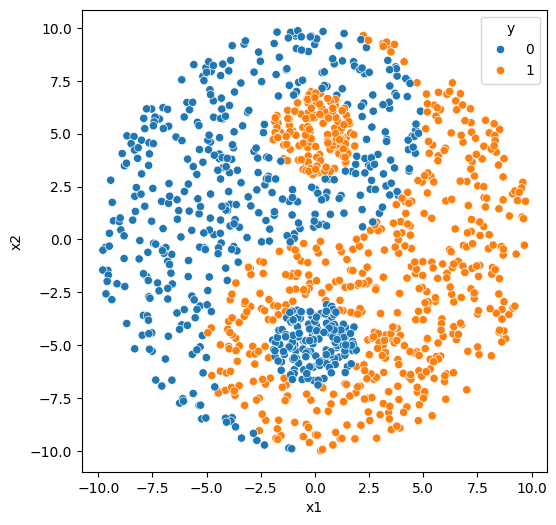

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dat = pd.DataFrame(x, columns=["x1", "x2"])
dat["y"] = y
plt.figure(figsize=(6, 6))
sns.scatterplot(data=dat, x="x1", y="x2", hue="y")

请在下方完成训练代码：

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim

# 将数据转换为 PyTorch 张量
x_train = torch.tensor(x, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# 构建 Logistic 回归模型
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

model = LogisticRegression(2)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 训练模型
num_epochs = 1000
for epoch in range(num_epochs):
    # 前向传播
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    
    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.5502
Epoch [200/1000], Loss: 0.5022
Epoch [300/1000], Loss: 0.5007
Epoch [400/1000], Loss: 0.5006
Epoch [500/1000], Loss: 0.5006
Epoch [600/1000], Loss: 0.5006
Epoch [700/1000], Loss: 0.5006
Epoch [800/1000], Loss: 0.5006
Epoch [900/1000], Loss: 0.5006
Epoch [1000/1000], Loss: 0.5006


完成模型训练后，利用得到的模型对如下测试集数据进行预测（概率 >0.5 判为1，反之判为0），计算分类的正确率。

In [49]:
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)

In [50]:
# 将测试数据转换为 PyTorch 张量
x_test = torch.tensor(xtest, dtype=torch.float32)
y_test = torch.tensor(ytest, dtype=torch.float32).reshape(-1, 1)

# 预测
model.eval()
with torch.no_grad():
    outputs = model(x_test)
    predictions = (outputs > 0.5).float()
    accuracy = (predictions == y_test).float().mean()

print(f"测试集分类正确率: {accuracy.item():.4f}")

测试集分类正确率: 0.6667


### 2.2 前馈神经网络

修改上面的线性模型，将其变为一个两层的前馈神经网络，隐藏神经元数量为32，使用 ReLU 激活函数。然后重新训练模型（可尝试使用不同的学习率和迭代次数），记录每次迭代的损失函数值并绘制损失函数值随迭代次数的曲线。最后对测试集进行预测，计算分类的正确率（目标是 >90%）。

Epoch [500/5000], Loss: 0.1284
Epoch [1000/5000], Loss: 0.0801
Epoch [1500/5000], Loss: 0.0513
Epoch [2000/5000], Loss: 0.0359
Epoch [2500/5000], Loss: 0.0284
Epoch [3000/5000], Loss: 0.0239
Epoch [3500/5000], Loss: 0.0206
Epoch [4000/5000], Loss: 0.0183
Epoch [4500/5000], Loss: 0.0165
Epoch [5000/5000], Loss: 0.0151


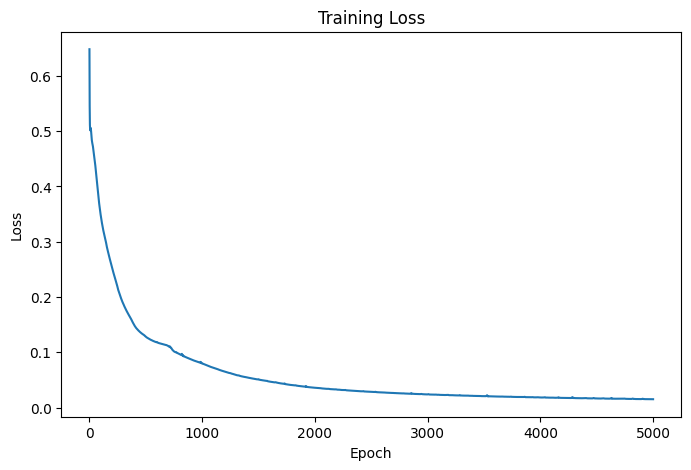

神经网络测试集分类正确率: 0.9583


In [51]:
# 构建两层前馈神经网络
class TwoLayerNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.layers(x)

model_nn = TwoLayerNN(2, 32)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.01)

# 训练模型并记录损失
num_epochs = 5000
loss_history = []

for epoch in range(num_epochs):
    outputs = model_nn(x_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 绘制损失曲线
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

# 测试集预测
model_nn.eval()
with torch.no_grad():
    outputs = model_nn(x_test)
    predictions = (outputs > 0.5).float()
    accuracy_nn = (predictions == y_test).float().mean()

print(f"神经网络测试集分类正确率: {accuracy_nn.item():.4f}")

### 2.3 Muon 优化器

请重新对上述前馈神经网络进行初始化和训练，但使用 Muon 优化器。**注意：Muon 只能对矩阵型参数进行优化，把向量型的参数传递给 Muon 会报错。**

请使用如下思路解决：构建两个优化器，Adam 和 Muon，将模型的参数分成两个列表，矩阵类的传递给 Muon，其他类的传递给 Adam，然后在训练循环中分别调用两个优化器的 `zero_grad()` 和 `step()` 函数。

请记录下这种方式下每次迭代的损失函数值，并与上一节中的曲线绘制在同一张图中进行对比。

Epoch [500/5000], Loss: 0.2334
Epoch [1000/5000], Loss: 0.1702
Epoch [1500/5000], Loss: 0.1491
Epoch [2000/5000], Loss: 0.1381
Epoch [2500/5000], Loss: 0.1311
Epoch [3000/5000], Loss: 0.1258
Epoch [3500/5000], Loss: 0.1218
Epoch [4000/5000], Loss: 0.1189
Epoch [4500/5000], Loss: 0.1161
Epoch [5000/5000], Loss: 0.1140


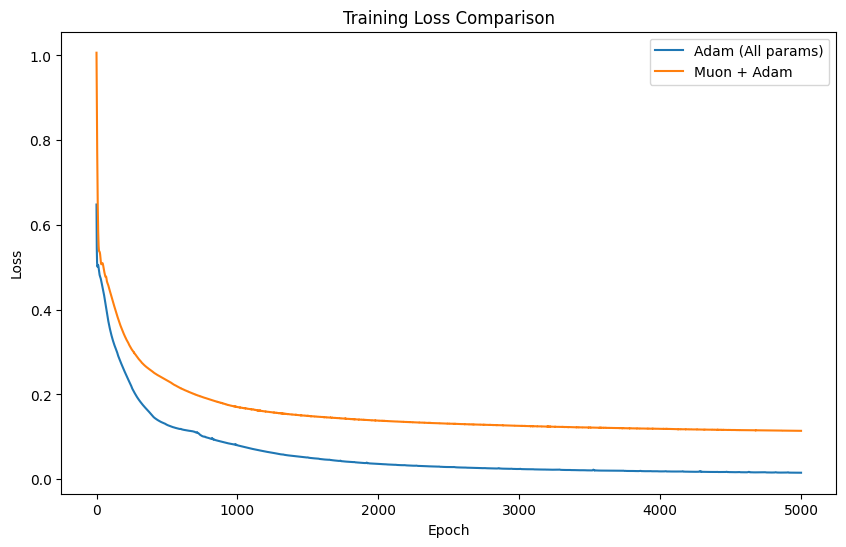

Muon+Adam 测试集分类正确率: 0.9208


In [ ]:

model_muon = TwoLayerNN(2, 32)
criterion = nn.BCELoss()

# 将参数分为矩阵型和向量型（简洁写法）
matrix_params = [p for p in model_muon.parameters() if p.dim() >= 2]
vector_params = [p for p in model_muon.parameters() if p.dim() < 2]

# 构建两个优化器
optimizer_muon = torch.optim.Muon(matrix_params, lr=0.01, momentum=0.95)
optimizer_adam = optim.Adam(vector_params, lr=0.01)

# 训练模型并记录损失
num_epochs = 5000
loss_history_muon = []

for epoch in range(num_epochs):
    outputs = model_muon(x_train)
    loss = criterion(outputs, y_train)
    
    # 两个优化器分别清零梯度
    optimizer_muon.zero_grad()
    optimizer_adam.zero_grad()
    
    loss.backward()
    
    # 两个优化器分别更新
    optimizer_muon.step()
    optimizer_adam.step()
    
    loss_history_muon.append(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 绘制损失曲线对比
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Adam (All params)')
plt.plot(loss_history_muon, label='Muon + Adam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.show()

# 测试集预测
model_muon.eval()
with torch.no_grad():
    outputs = model_muon(x_test)
    predictions = (outputs > 0.5).float()
    accuracy_muon = (predictions == y_test).float().mean()

print(f"Muon+Adam 测试集分类正确率: {accuracy_muon.item():.4f}")


## 3. 预训练模型实战

请学习语音识别模型 Whisper 的使用方法（访问 [https://hf-mirror.com/openai/whisper-small](https://hf-mirror.com/openai/whisper-small) 或 [https://huggingface.co/openai/whisper-small](https://huggingface.co/openai/whisper-small)），完成以下任务：

1. 准备一段文字（内容任意，朗读出来大约10秒钟），填写在下方的文本框里。
2. 朗读这段文字，利用录音软件录制一段10秒左右的音频，保存为 `.wav` 格式。
3. 根据网站上的文档学习使用 Whisper 预训练模型，将预训练模型下载到本地，并识别你录制的音频，将其转为文字，打印出来。
4. 配备有 Nvidia GPU 的同学可以尝试参数量更大的 Whisper-Large 模型（访问 [https://hf-mirror.com/openai/whisper-large-v3](https://hf-mirror.com/openai/whisper-large-v3) 或 [https://huggingface.co/openai/whisper-large-v3](https://huggingface.co/openai/whisper-large-v3)），在 CUDA 模式下运行模型。

真实文字内容：【你好，今天是星期六，天气晴朗，可是我的心情不太美妙】

语音文件的文件名：【recording.wav】

In [ ]:
!pip install -U openai-whisper
!pip install ffmpeg-python

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch
import librosa

# 加载模型（第一次会自动下载到本地缓存）
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")

# 读取音频，强制重采样到 16kHz
audio, sr = librosa.load("secrecording.wav", sr=16000)
input_features = processor(
    audio, 
    sampling_rate=16000, 
    return_tensors="pt"
).input_features

# 强制中文语音识别
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="chinese", 
    task="transcribe"
)

# 推理
with torch.no_grad():
    predicted_ids = model.generate(input_features, forced_decoder_ids=forced_decoder_ids)

# 解码输出
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)
print(transcription[0])


Loading weights: 100%|██████████| 479/479 [00:00<00:00, 1936.27it/s]
C:\Users\sunny\AppData\Local\Temp\ipykernel_13004\3746330561.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load("secrecording.wav", sr=16000)


你好,今天是星期六,天氣晴朗可是我的心情不太美妙
